In [192]:
import numpy as np
import pandas as pd
import seaborn as sns
import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
from NG_FWI import hFWI
#from nfdrs4_live import GSILimits, SetGSILimits, fetch_daily_meteo_data, predict_nfdrs_live_per_location, calcGSI, calc_gsi
from lfmc_nfdrs4 import calc_gsi, fetch_daily_meteo_data
from model_base import LiveFuelMoistureModel
from model_comparison import fetch_meteo_data
from scipy.stats import spearmanr, stats, linregress
from sklearn.metrics import mean_absolute_error, r2_score


In [2]:
lfmc_model = LiveFuelMoistureModel()
dfrl = lfmc_model.prepare_training_dataset(
    fname="data/training_dataset_features_full.parquet"
)
dfrl = dfrl.rename({'date': 'datetime'}, axis=1)
dfrl['date'] = dfrl.datetime.dt.date

In [172]:
hc = dfrl[(dfrl.fuel == "Heather canopy")].copy()

In [ ]:
def fetch_weather(dfr, group_cols=['lonind', 'latind']):
    grouped = dfr.groupby(group_cols)
    for group_key, val_df in grouped:
        pred_df = val_df.copy()
        start_date = (pred_df.date.min() - pd.Timedelta(days=60)).strftime("%Y-%m-%d")
        end_date = (pred_df.date.max()).strftime("%Y-%m-%d")
        wx = fetch_daily_meteo_data(
            pred_df.latitude.iloc[0], pred_df.longitude.iloc[0], start_date, end_date
        )
        #wx = calcGSI(wx, gsilim)
        pred_df = pd.merge(pred_df, wx[["date", "LFMC"]], on="date")
        predictions.append(pred_df)
        wx[group_cols] = pred_df[group_cols].iloc[0].values
        time_series.append(wx)
 

In [274]:
hc.groupby(['lonind', 'latind'])["site"].count()

lonind  latind
1761    1484       6
1764    1412      68
1769    1419      17
1770    1419      20
1781    1434      18
        1436      16
1782    1434      29
1791    1444      37
1793    1412      26
        1413      19
        1443      15
        1444      35
1794    1414      25
1796    1413      25
1807    1425       1
1808    1425      27
Name: site, dtype: int64

In [270]:
hc.lonind

4       1808
35      1808
86      1808
88      1808
96      1808
        ... 
5784    1791
5804    1794
5824    1782
5830    1781
5834    1781
Name: lonind, Length: 384, dtype: int64

In [179]:
x = hc.datetime.dt.day_of_year
y = hc['fmc_%']

In [197]:
hc['doy']=hc.datetime.dt.day_of_year
hc['lfmc']=hc['fmc_%']

In [284]:
data = hc[hc.year==2021][['doy', 'lfmc']].sort_values('doy')
data = data[data.lfmc<175]

In [282]:
az.style.use("arviz-darkgrid")

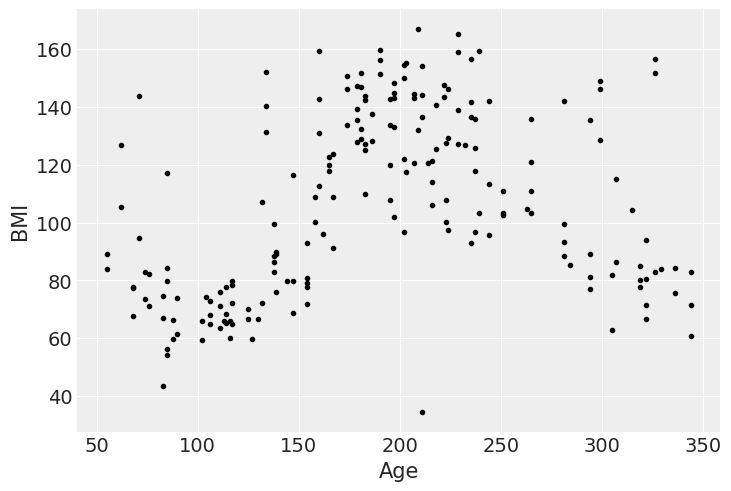

In [285]:
plt.plot(data.doy, data.lfmc, "k.");
plt.xlabel("Age")
plt.ylabel("BMI");

In [286]:
quantiles = np.array([0.1, 0.5, 0.9])
kappas = (quantiles/(1-quantiles))**0.5

#knots = np.quantile(hc.doy, np.linspace(0, 1, 4))[1:-1]
knots = [100, 160, 300]
idatas = []
for κ in kappas:
    model = bmb.Model(
        "lfmc ~ bs(doy, knots=knots)",
        data=data,
        family="asymmetriclaplace",
        priors={"kappa": κ}
    )
    idata = model.fit()
    model.predict(idata)
    idatas.append(idata)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, Intercept, bs(doy, knots=knots)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, Intercept, bs(doy, knots=knots)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b, Intercept, bs(doy, knots=knots)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


In [266]:
knots

array([138., 202.])

In [261]:
knots = np.quantile(hc.doy, np.linspace(0, 1, 10))[1:-1]
knots

array([ 74.        , 114.        , 138.        , 167.22222222,
       194.        , 202.        , 223.88888889, 265.        ])

In [262]:
knots = [100, 160, 300]

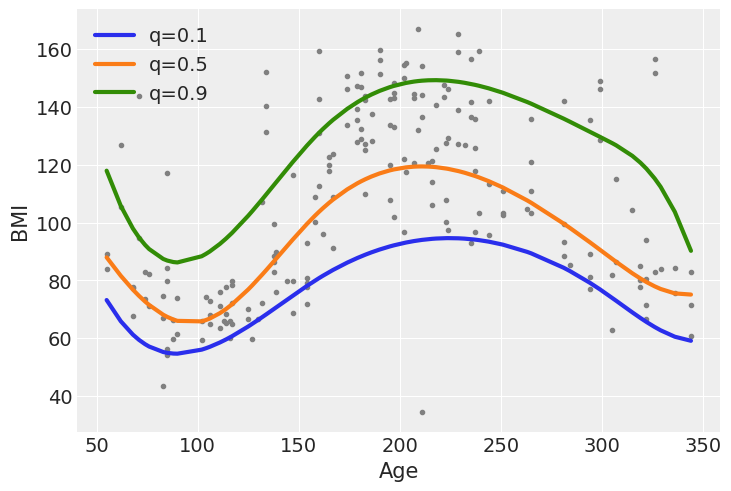

In [287]:
plt.plot(data.doy, data.lfmc, ".", color="0.5")
for idata, q in zip(idatas, quantiles):
    plt.plot(
        data.doy.values,
        idata.posterior["mu"].mean(("chain", "draw")),
        label=f"q={q:}",
        lw=3
    );

plt.legend()
plt.xlabel("Age")
plt.ylabel("BMI");

In [219]:
data['rad']=np.deg2rad(data['doy'])

In [221]:
model_n = bmb.Model("lfmc ~ doy", data)
idata_n = model_n.fit(include_response_params=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, doy]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


In [220]:
model_vm = bmb.Model("lfmc ~ rad", data, family="vonmises")
idata_vm = model_vm.fit(include_response_params=True)

Initializing NUTS using jitter+adapt_diag...


SamplingError: Initial evaluation of model at starting point failed!
Starting values:
{'kappa_log__': array(0.55118982), 'Intercept': array(-0.90036856), 'rad': array(0.88008795)}

Logp initial evaluation results:
{'kappa': np.float64(-1.14), 'Intercept': np.float64(-2.76), 'rad': np.float64(-1.68), 'lfmc': np.float64(-inf)}
You can call `model.debug()` for more details.

In [211]:
idata

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [277]:
sns.scatterplot(data=hc, x="date", y="fmc_%", hue=["lonind", "latind"])
plt.show()

ValueError: Length of list vectors must match length of `data` when both are used, but `data` has length 384 and the vector passed to `hue` has length 2.

In [5]:
lonind = 1764
latind = 1412
sub_hc = dfrl[
    (dfrl.lonind == lonind)
    & (dfrl.latind == latind)
    & (dfrl.fuel == "Heather canopy")
].copy()
#sub_hc["date"] = sub_hc.datetime.dt.date
start_date = (sub_hc.datetime.min() - pd.Timedelta(days=30)).strftime("%Y-%m-%d")
end_date = (sub_hc.datetime.max()).strftime("%Y-%m-%d")
wx = fetch_daily_meteo_data(
    sub_hc.latitude.iloc[0], sub_hc.longitude.iloc[0], start_date, end_date
)
wx['date'] = wx.datetime.dt.date
 

In [6]:
weather = wx.copy()

In [162]:
def SetGSILimits(gsilim, gsiparams, LFMMin, LFMMax, Lat):
    gsilim.TminLow = gsiparams[-2]
    gsilim.TminUp = gsiparams[6]
    gsilim.VPDLow = gsiparams[2]
    gsilim.VPDUp = gsiparams[3]
    gsilim.DaylLow = gsiparams[4]
    gsilim.DaylUp = gsiparams[5]
    gsilim.PrcpRTLow = gsiparams[6]
    gsilim.PrcpRTUp = gsiparams[7]
    gsilim.GSIPeriod = gsiparams[8]
    gsilim.GUThresh = gsiparams[9]
    gsilim.PrcpRTPeriod = gsiparams[10]
    gsilim.LFMMin = LFMMin
    gsilim.LFMMax = LFMMax
    gsilim.Lat = Lat
    return gsilim



In [66]:
#gsiparams = [-5, -4, 1.7, 8.5, 32400, 43200, 22, 39, 56, 0, 56]
#gsiparams = [-1, 9, 0.5, 4, 32400, 43200, 0, 50, 27, 0.3, 27]
gsiparams = [0, 4, 0.9, 4.8, 20000, 26000, 0, 40, 27, 0.3, 27]
gsilim = GSILimits
gsilim = SetGSILimits(gsilim, gsiparams, 60, 170, 52)
#wxo = wx.copy()

old = calcGSI(wx.copy(), gsilim)


In [37]:
def calc_ramp_index(values: np.ndarray, min_val: float, max_val: float) -> np.ndarray:
    ramp_index = (values - min_val) / (max_val - min_val)
    ramp_index[values < min_val] = 0
    ramp_index[values > max_val] = 1
    return ramp_index

def calc_ramp_index(values: np.ndarray, min_val: float, max_val: float) -> np.ndarray:
    ramp_index = (values - min_val) / (max_val - min_val)
    ramp_index[values < min_val] = 0
    ramp_index[values > max_val] = 1
    return ramp_index


def calc_lfmc_from_gsi(
    gsi: np.ndarray, gu_thresh: float, lfmc_min: float, lfmc_max: float
) -> np.ndarray:
    m = (lfmc_max - lfmc_min) / (1 - gu_thresh)
    b = lfmc_max - m
    lfmc = (m * gsi) + b
    lfmc[gsi < gu_thresh] = lfmc_min
    return lfmc


def calc_gsi(df: pd.DataFrame, gsilim, return_intermediate=False) -> pd.DataFrame:
    """Calculate live fuel moisture using the ramp functions with limits
    given in the gsilim dict"""
    # Min temp index
    temp_min_ind = calc_ramp_index(
        df["temperature_2m_min"].values, gsilim["TminLow"], gsilim["TminUp"]
    )
    # Vapor Pressure Deficit
    vpd_max_ind = 1 - (
        calc_ramp_index(
            df["vapour_pressure_deficit_max"].values, gsilim["VPDLow"], gsilim["VPDUp"]
        )
    )
    # Photoperiod / Daylength
    day_len_ind = calc_ramp_index(
        df["daylight_duration"].values, gsilim["DaylLow"], gsilim["DaylUp"]
    )
    # Running Total Precipitation
    prec_roll = (
        df["precipitation_sum"]
        .rolling(gsilim["PrcpRTPeriod"], min_periods=1)
        .sum()
        .values
    )
    prec_ind = calc_ramp_index(prec_roll, gsilim["PrcpRTLow"], gsilim["PrcpRTUp"])

    # Daily GSI for four ramp model
    i_gsi_pe = temp_min_ind * vpd_max_ind * prec_ind
    # Smoothed GSI (running average over the GSIPeriod)
    gsi_pe = np.convolve(
        i_gsi_pe, np.ones(gsilim["GSIPeriod"]) / gsilim["GSIPeriod"], mode="same"
    )
    # Rescale the final GSI time series
    gsi_pe_rs = gsi_pe / gsi_pe.max()
    # GSI to LFMC
    lfmc = calc_lfmc_from_gsi(
        gsi_pe_rs, gsilim["GUThresh"], gsilim["LFMMin"], gsilim["LFMMax"]
    )

    if not return_intermediate:
        df["LFMC"] = lfmc
    else:
        intermediate = pd.DataFrame(
            {
                "TminInd": temp_min_ind,
                "VPDInd": vpd_max_ind,
                "DaylInd": day_len_ind,
                "PrcpInd": prec_ind,
                "iGSI_PE": i_gsi_pe,
                "GSI_PE": gsi_pe,
                "GSI_PE_RS": gsi_pe_rs,
                "LFMC": lfmc,
            }
        )
        df = pd.concat([df, intermediate], axis=1)
    return df

In [167]:
gsi_params = {'TminLow': np.float64(-2.0),
 'TminUp': np.float64(10.0),
 'VPDLow': np.float64(0.9),
 'VPDUp': np.float64(2.799999999999999),
 'DaylLow': np.float64(20000.0),
 'DaylUp': np.float64(36000.0),
 'PrcpRTLow': np.float64(0.0),
 'PrcpRTUp': np.float64(10.0),
 'LFMMin': np.float64(60.0),
 'LFMMax': np.float64(155.0),
 'PrcpRTPeriod': np.int64(47),
 'GSIPeriod': np.int64(24),
 'GUThresh': np.float64(0.25)}

In [168]:
we = calc_gsi(weather, gsi_params, return_intermediate=True)

In [46]:
%timeit calcGSI(wxo, gsilim)

18.9 ms ± 1.24 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [47]:
%timeit calc_gsi(wx, gsilim, return_intermediate=True)

743 μs ± 66.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [48]:
%timeit calc_gsi(wx, gsilim, return_intermediate=False)

370 μs ± 22.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [165]:
we

,datetime,daylight_duration,vapour_pressure_deficit_max,temperature_2m_min,precipitation_sum,date,TminInd,VPDInd,DaylInd,PrcpInd,iGSI_PE,GSI_PE,GSI_PE_RS,LFMC
0,2021-03-28 00:00:00+00:00,45742.886719,0.169455,5.678,3.1,2021-03-28,1.000000,1.000000,1.0,0.31,0.310000,0.122142,0.122142,60.000000
1,2021-03-29 00:00:00+00:00,45973.558594,0.698665,5.228,0.0,2021-03-29,1.000000,1.000000,1.0,0.31,0.310000,0.142138,0.142138,60.000000
2,2021-03-30 00:00:00+00:00,46204.765625,1.106557,5.928,0.3,2021-03-30,1.000000,0.891286,1.0,0.34,0.303037,0.155698,0.155698,60.000000
3,2021-03-31 00:00:00+00:00,46436.683594,0.850812,7.878,0.4,2021-03-31,1.000000,1.000000,1.0,0.38,0.380000,0.160031,0.160031,60.000000
4,2021-04-01 00:00:00+00:00,46669.171875,0.339934,3.778,2.2,2021-04-01,0.825429,1.000000,1.0,0.60,0.495257,0.163769,0.163769,60.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789,2023-05-26 00:00:00+00:00,57736.964844,0.883044,8.028,0.0,2023-05-26,1.000000,1.000000,1.0,1.00,1.000000,0.690009,0.690009,115.734436
790,2023-05-27 00:00:00+00:00,57874.308594,1.084362,4.828,0.0,2023-05-27,0.975429,0.902968,1.0,1.00,0.880780,0.648342,0.648342,110.456659
791,2023-05-28 00:00:00+00:00,58007.601562,0.778877,8.028,0.0,2023-05-28,1.000000,1.000000,1.0,1.00,1.000000,0.606675,0.606675,105.178881
792,2023-05-29 00:00:00+00:00,58136.656250,0.628582,7.028,0.0,2023-05-29,1.000000,1.000000,1.0,1.00,1.000000,0.573473,0.573473,100.973246


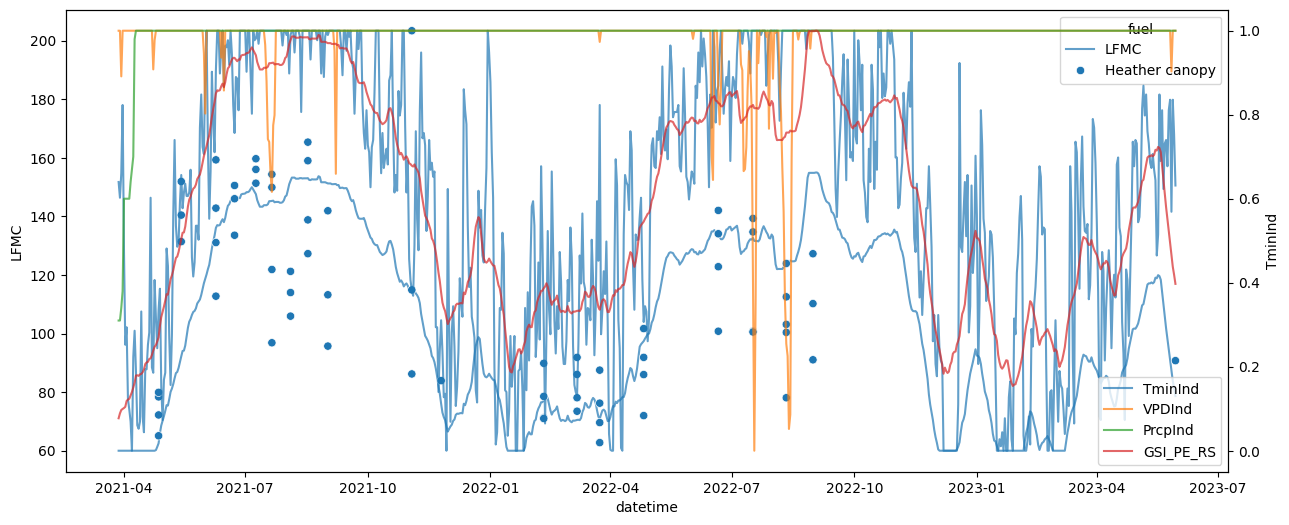

In [169]:
fig = plt.figure(figsize=(15, 6))
ax = fig.add_subplot(111)
ax2 = ax.twinx()
sns.lineplot(data=we, x='date', y='TminInd', alpha=0.7, ax=ax2, label='TminInd')
sns.lineplot(data=we, x='date', y='VPDInd', alpha=0.7, ax=ax2, label='VPDInd')
#sns.lineplot(data=we, x='date', y='DaylInd', alpha=0.7, ax=ax2, label='DaylInd')
sns.lineplot(data=we, x='date', y='PrcpInd', alpha=0.7, ax=ax2, label='PrcpInd')
sns.lineplot(data=we, x='date', y='GSI_PE_RS', alpha=0.7, ax=ax2, label='GSI_PE_RS')
#sns.lineplot(data=we, x='date', y='iGSI_PE', alpha=0.7, ax=ax2, label='iGSI_PE')
sns.lineplot(data=we, x='datetime', y='LFMC', alpha=0.7, ax=ax, label='LFMC')
sns.scatterplot(data=sub_hc, x="date", y="fmc_%", hue="fuel", ax=ax, zorder=100)
#ax.get_legend().remove()
#ax.set_ylim(-2, 40)
plt.show()

In [42]:
merged = we.merge(sub_hc[["date", "fmc_%"]], on="date", how="left")

In [43]:
_, _, r_value, _, _ = linregress(
    merged.dropna()["fmc_%"], merged.dropna()["LFMC"]
)

r2 = r_value**2


In [44]:
r2

np.float64(0.4977439509890445)

<Axes: xlabel='fmc_%', ylabel='LFMC'>

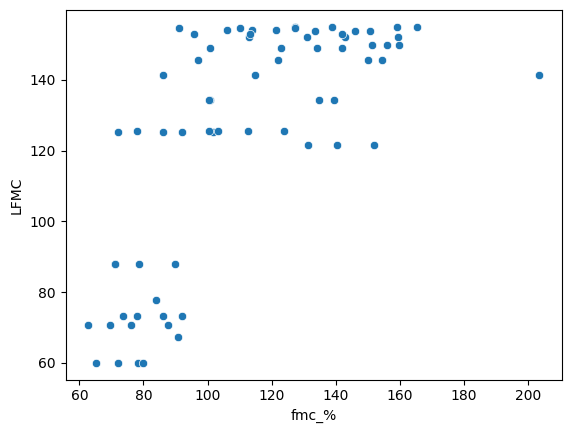

In [45]:
sns.scatterplot(data=merged, x='fmc_%', y='LFMC')

In [31]:
gsi_params

{'TminLow': np.int64(0),
 'TminUp': np.int64(4),
 'VPDLow': np.float64(0.9),
 'VPDUp': np.float64(4.799999999999999),
 'DaylLow': np.int64(20000),
 'DaylUp': np.int64(26000),
 'PrcpRTLow': np.int64(0),
 'PrcpRTUp': np.int64(40),
 'LFMMin': np.int64(60),
 'LFMMax': np.int64(160),
 'PrcpRTPeriod': np.int64(60),
 'GSIPeriod': np.int64(20),
 'GUThresh': np.float64(0.7000000000000001)}

In [42]:
m = (gsi_params['LFMMax'] - gsi_params['LFMMin']) / (1 - gsi_params['GUThresh'])
b = gsi_params['LFMMax'] - m
lfmc = (m * we['GSI_PE_RS']) + b
lfmc[we['GSI_PE_RS'] < gsi_params['GUThresh']] = gsi_params['LFMMin']


In [37]:
print(m, b)

333.3333333333334 -173.33333333333343


In [39]:
we.GSI_PE_RS

0      0.028401
1      0.028401
2      0.029884
3      0.034258
4      0.035265
         ...   
789    0.742361
790    0.697636
791    0.647636
792    0.597636
793    0.547636
Name: GSI_PE_RS, Length: 794, dtype: float64

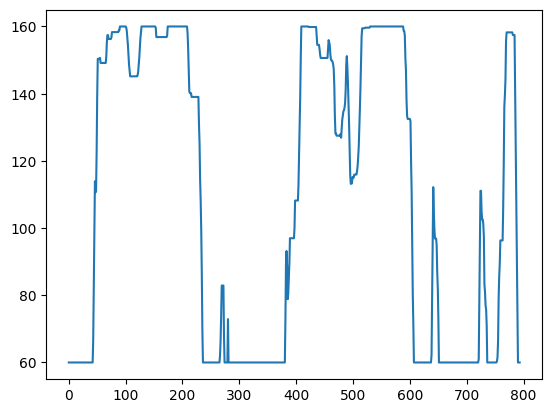

In [43]:
plt.plot(lfmc)

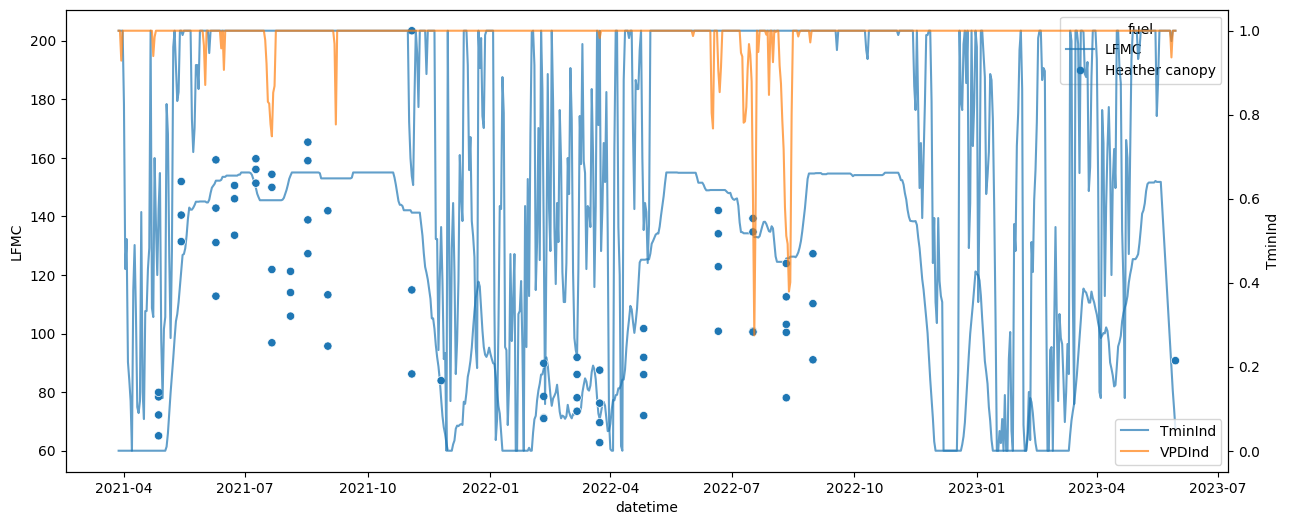

In [148]:
fig = plt.figure(figsize=(15, 6))
ax = fig.add_subplot(111)
ax2 = ax.twinx()
sns.lineplot(data=we, x='date', y='TminInd', alpha=0.7, ax=ax2, label='TminInd')
sns.lineplot(data=we, x='date', y='VPDInd', alpha=0.7, ax=ax2, label='VPDInd')
#sns.lineplot(data=we, x='date', y='DaylInd', alpha=0.7, ax=ax2, label='DaylInd')
#sns.lineplot(data=we, x='date', y='PrcpInd', alpha=0.7, ax=ax2, label='PrcpInd')
#sns.lineplot(data=wxn, x='date', y='GSI_PE_RS', alpha=0.7, ax=ax2, label='GSI_PE_RS')w
#sns.lineplot(data=wxn, x='date', y='iGSI_PE', alpha=0.7, ax=ax2, label='iGSI_PE')
sns.lineplot(data=we, x='datetime', y='LFMC', alpha=0.7, ax=ax, label='LFMC')
sns.scatterplot(data=sub_hc, x="date", y="fmc_%", hue="fuel", ax=ax, zorder=100)
#ax.get_legend().remove()
#ax.set_ylim(-2, 40)
plt.show()

In [52]:
wx

,datetime,daylight_duration,vapour_pressure_deficit_max,temperature_2m_min,precipitation_sum,date,LFMC
0,2021-03-28 00:00:00+00:00,45742.886719,0.169455,5.678,3.1,2021-03-28,14.352163
1,2021-03-29 00:00:00+00:00,45973.558594,0.698665,5.228,0.0,2021-03-29,14.352163
2,2021-03-30 00:00:00+00:00,46204.765625,1.106557,5.928,0.3,2021-03-30,14.352163
3,2021-03-31 00:00:00+00:00,46436.683594,0.850812,7.878,0.4,2021-03-31,14.352163
4,2021-04-01 00:00:00+00:00,46669.171875,0.339934,3.778,2.2,2021-04-01,14.352163
...,...,...,...,...,...,...,...
789,2023-05-26 00:00:00+00:00,57736.964844,0.883044,8.028,0.0,2023-05-26,99.598404
790,2023-05-27 00:00:00+00:00,57874.308594,1.084362,4.828,0.0,2023-05-27,93.702779
791,2023-05-28 00:00:00+00:00,58007.601562,0.778877,8.028,0.0,2023-05-28,87.807783
792,2023-05-29 00:00:00+00:00,58136.656250,0.628582,7.028,0.0,2023-05-29,82.546433


In [68]:
MetLFMMerge = sub_hc.merge(old[["date", "LFMC"]], on="date")

# Compare the GSI-LFMC (NFDRS-V4) to measured LFMC
s2, p2 = spearmanr(MetLFMMerge["fmc_%"], MetLFMMerge["LFMC"], nan_policy="omit")
mae2 = mean_absolute_error(MetLFMMerge["fmc_%"], MetLFMMerge["LFMC"])
slope, intercept, r_value, p_value_def, std_err = linregress(
    MetLFMMerge["fmc_%"], MetLFMMerge["LFMC"]
)
r2 = r_value**2
 

In [69]:
s2

np.float64(0.6256963910676637)

In [72]:
def calc_lfmc_from_gsi(gsi, gu_thresh, lfmc_min, lfmc_max):
    m = (lfmc_max - lfmc_min) / (1 - gu_thresh)
    b = lfmc_max - m
    lfmc = (m * gsi) + b
    lfmc[lfmc < gu_thresh] = lfmc_min
    return lfmc

## Function to transform GSI to LFMC
def CalcLFMFromGSI(gsi, GUThresh, LFMMin, LFMMax):
    m = (LFMMax - LFMMin) / (1 - GUThresh)
    b = LFMMax - m
    # Scale GSI between min and max LFMC if gsi is above the green-up threshold
    if gsi >= GUThresh:
        LFM = m * gsi + b
    # Below the Green-up Threshold, set the value to minimum LFM
    else:
        LFM = LFMMin
    return LFM



In [71]:
wxn.LFMC.min()

np.float64(12.857142857142861)

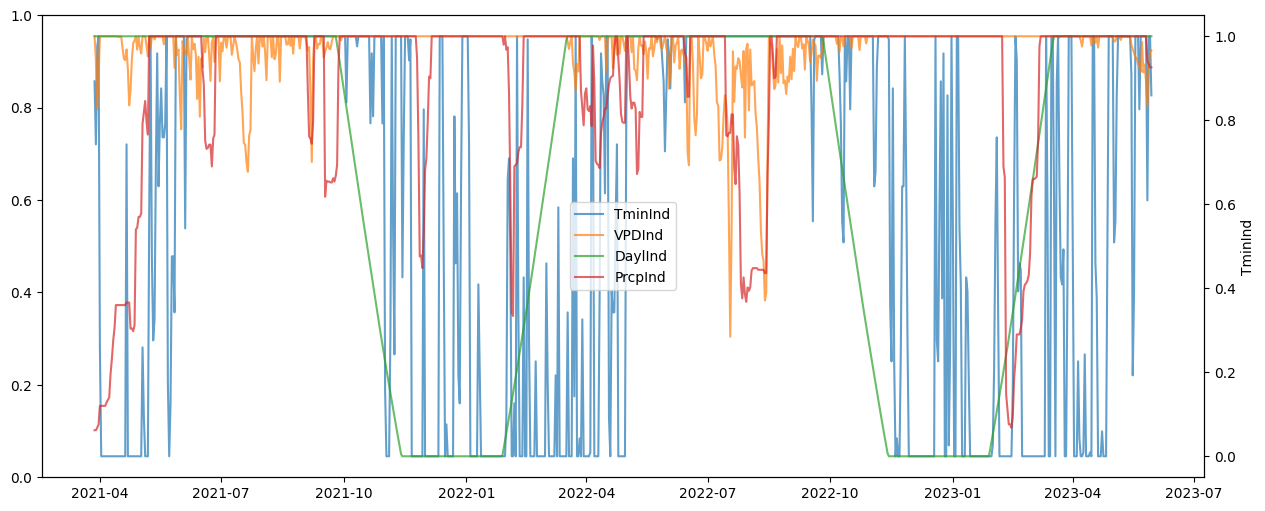

In [75]:
fig = plt.figure(figsize=(15, 6))
ax = fig.add_subplot(111)
ax2 = ax.twinx()
sns.lineplot(data=old, x='date', y='TminInd', alpha=0.7, ax=ax2, label='TminInd')
sns.lineplot(data=old, x='date', y='VPDInd', alpha=0.7, ax=ax2, label='VPDInd')
sns.lineplot(data=old, x='date', y='DaylInd', alpha=0.7, ax=ax2, label='DaylInd')
sns.lineplot(data=old, x='date', y='PrcpInd', alpha=0.7, ax=ax2, label='PrcpInd')
#sns.lineplot(data=old, x='date', y='GSI_PE_RS', alpha=0.7, ax=ax2, label='GSI_PE_RS')
#sns.lineplot(data=old, x='date', y='iGSI_PE', alpha=0.7, ax=ax2, label='iGSI_PE')
#sns.lineplot(data=old, x='date', y='LFMC', alpha=0.7, ax=ax, label='LFMC')
#sns.scatterplot(data=sub_hc, x="date", y="fmc_%", hue="fuel", ax=ax, zorder=100)
#ax.get_legend().remove()
#ax.set_ylim(-2, 40)
fig.savefig('/media/sf_shared/ramp_indexes_example.png', dpi=300, bbox_inches="tight")
plt.show()

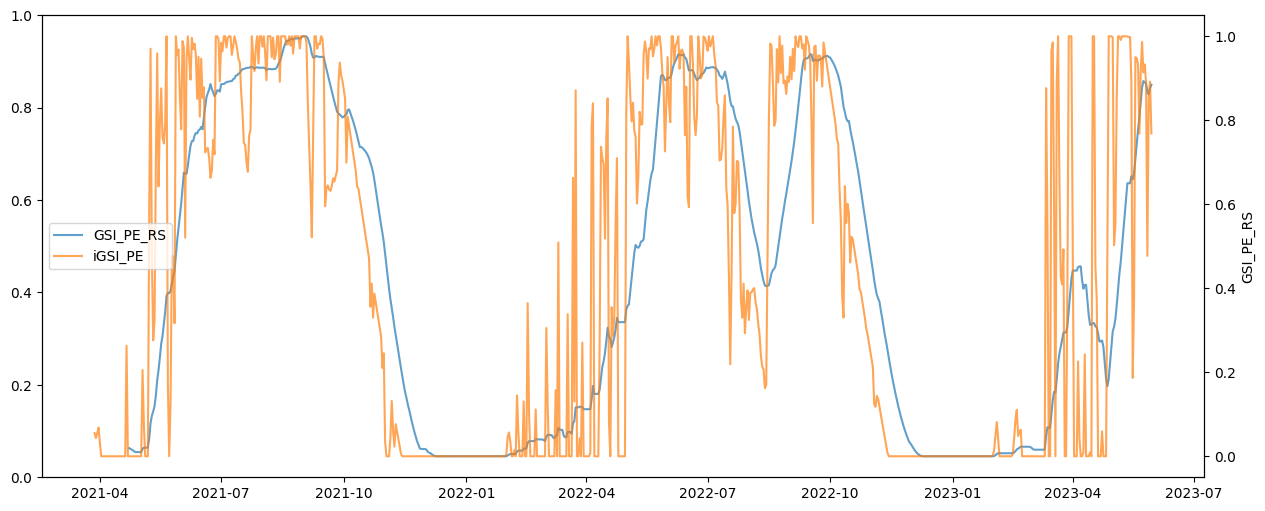

In [77]:
fig = plt.figure(figsize=(15, 6))
ax = fig.add_subplot(111)
ax2 = ax.twinx()
#sns.lineplot(data=old, x='date', y='TminInd', alpha=0.7, ax=ax2, label='TminInd')
#sns.lineplot(data=old, x='date', y='VPDInd', alpha=0.7, ax=ax2, label='VPDInd')
#sns.lineplot(data=old, x='date', y='DaylInd', alpha=0.7, ax=ax2, label='DaylInd')
#sns.lineplot(data=old, x='date', y='PrcpInd', alpha=0.7, ax=ax2, label='PrcpInd')
sns.lineplot(data=old, x='date', y='GSI_PE_RS', alpha=0.7, ax=ax2, label='GSI_PE_RS')
sns.lineplot(data=old, x='date', y='iGSI_PE', alpha=0.7, ax=ax2, label='iGSI_PE')
#sns.lineplot(data=old, x='date', y='LFMC', alpha=0.7, ax=ax, label='LFMC')
#sns.scatterplot(data=sub_hc, x="date", y="fmc_%", hue="fuel", ax=ax, zorder=100)
#ax.get_legend().remove()
#ax.set_ylim(-2, 40)
fig.savefig('/media/sf_shared/ramp_func_product.png', dpi=300, bbox_inches="tight")
plt.show()

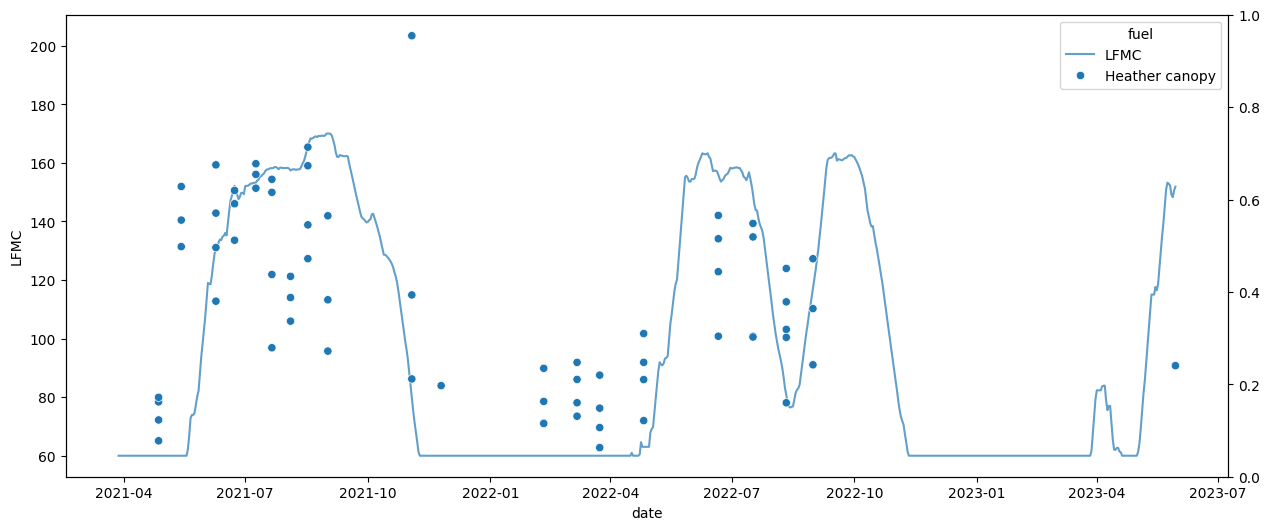

In [79]:
fig = plt.figure(figsize=(15, 6))
ax = fig.add_subplot(111)
ax2 = ax.twinx()
#sns.lineplot(data=old, x='date', y='TminInd', alpha=0.7, ax=ax2, label='TminInd')
#sns.lineplot(data=old, x='date', y='VPDInd', alpha=0.7, ax=ax2, label='VPDInd')
#sns.lineplot(data=old, x='date', y='DaylInd', alpha=0.7, ax=ax2, label='DaylInd')
#sns.lineplot(data=old, x='date', y='PrcpInd', alpha=0.7, ax=ax2, label='PrcpInd')
#sns.lineplot(data=old, x='date', y='GSI_PE_RS', alpha=0.7, ax=ax2, label='GSI_PE_RS')
#sns.lineplot(data=old, x='date', y='iGSI_PE', alpha=0.7, ax=ax2, label='iGSI_PE')
sns.lineplot(data=old, x='date', y='LFMC', alpha=0.7, ax=ax, label='LFMC')
sns.scatterplot(data=sub_hc, x="date", y="fmc_%", hue="fuel", ax=ax, zorder=100)
#ax.get_legend().remove()
#ax.set_ylim(-2, 40)
fig.savefig('/media/sf_shared/lfmc_heather_example.png', dpi=300, bbox_inches="tight")
plt.show()

ValueError: Data must be 1-dimensional, got ndarray of shape (794, 2) instead

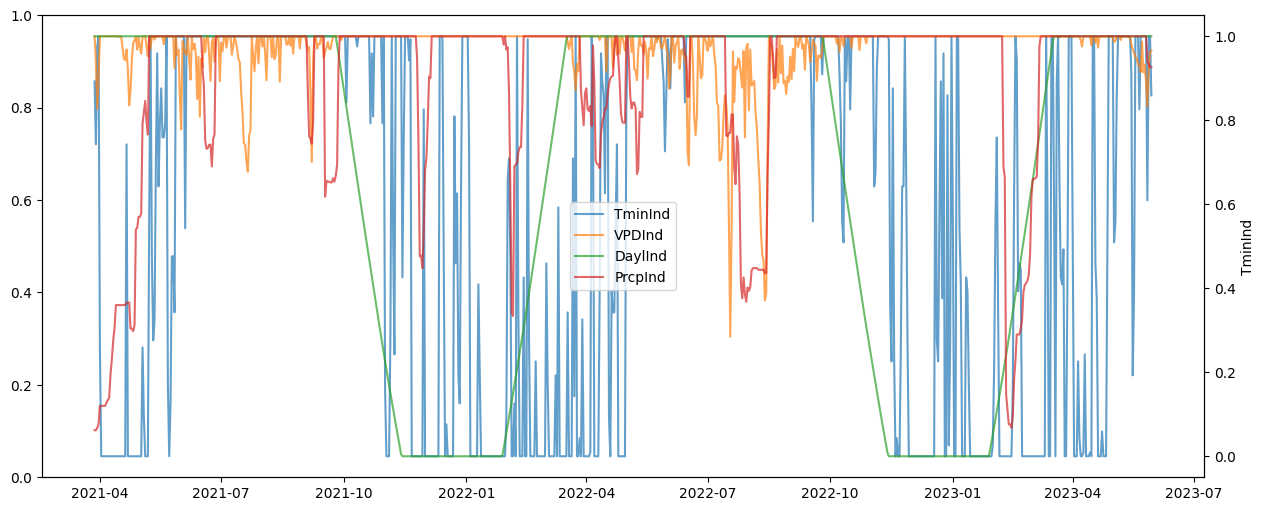

In [55]:
fig = plt.figure(figsize=(15, 6))
ax = fig.add_subplot(111)
ax2 = ax.twinx()
sns.lineplot(data=wxn, x='date', y='TminInd', alpha=0.7, ax=ax2, label='TminInd')
sns.lineplot(data=wxn, x='date', y='VPDInd', alpha=0.7, ax=ax2, label='VPDInd')
sns.lineplot(data=wxn, x='date', y='DaylInd', alpha=0.7, ax=ax2, label='DaylInd')
sns.lineplot(data=wxn, x='date', y='PrcpInd', alpha=0.7, ax=ax2, label='PrcpInd')
#sns.lineplot(data=wx, x='date', y='GSI_PE_RS', alpha=0.7, ax=ax2, label='GSI_PE_RS')
#sns.lineplot(data=sub, x='date', y='iGSI_PE', alpha=0.7, ax=ax2, label='iGSI_PE')
sns.lineplot(data=wxn, x='date', y='LFMC', alpha=0.7, ax=ax, label='LFMC')
sns.scatterplot(data=sub_hc, x="date", y="fmc_%", hue="fuel", ax=ax, zorder=100)
#ax.get_legend().remove()
#ax.set_ylim(-2, 40)
plt.show()

In [46]:
gl = pd.read_parquet('data/globe_lfmc_2.parquet')

In [47]:
gl.columns

Index(['Site name', 'Country', 'State/Region', 'latitude', 'longitude', 'date',
       'lfmc', 'Species collected', 'Species functional type',
       'Individual sample or mean value', 'Old or new leaves',
       'Isolated data point', 'IGBP Land Cover', 'IGBP Land Cover ID',
       'Year of Land Cover', 'Precipitation 24h sum (mm/day)',
       'Precipitation sum 3 days before (mm/day)',
       'Precipitation sum 1 week before (mm/day)',
       'Precipitation sum 4 weeks before (mm/day)',
       'Precipitation sum 12 weeks before (mm/day)',
       '2m Relative Humidity at 06h (%)', '2m Relative Humidity at 09h (%)',
       '2m Relative Humidity at 12h (%)', '2m Relative Humidity at 15h (%)',
       '2m Air Temperature 24h max (K)', '2m Air Temperature 24h mean (K)',
       'Vapour Pressure 24h mean (hPa)', '10m Wind Speed 24h mean (m/s)',
       '2m Dewpoint Temperature 24h mean (K)', 'latind', 'lonind'],
      dtype='str')

In [45]:
gl.groupby('Country')['Species collected'].count()

Country
Argentina          241
Australia         3355
China              264
England             26
France           24169
Israel            2215
Italy             2630
Portugal            53
Scotland           255
Senegal             96
South Africa       950
Spain            18663
Tunisia            449
Türkiye            689
USA             239741
Name: Species collected, dtype: int64

In [57]:
eu_countries = ['France', 'Italy', 'Scotland', 'Spain', 'Tunisia', 'Türkiye', 'Israel']
egl = gl[gl.Country.isin(eu_countries)]
tegl = egl[(egl['Species functional type'] == 'Tree')&(egl['Isolated data point']==False)]


In [58]:
tegl['Isolated data point'].value_counts()

Isolated data point
False    8185
Name: count, dtype: int64

In [60]:
tegl['Species collected'].value_counts()

Species collected
Quercus ilex                            3138
Pinus halepensis                        2504
Acacia dealbata                          395
Quercus faginea                          279
Quercus pubescens                        270
Pistacia palaestina                      216
Olea europaea                            189
Styrax officinalis                       123
Cercis siliquastrum                      108
Quercus infectoria                       108
Quercus suber                            103
Phillyrea latifolia                       81
Pinus sylvestris                          75
Quercus calliprinos                       68
Pinus brutia                              61
Pistacia atlantica                        57
Quercus ithaburensis                      54
Pinus pinaster                            41
Pinus nigra laricio                       34
Ailanthus altissima                       23
Populus alba                              23
Robinia pseudoacacia                 

<Axes: xlabel='date', ylabel='lfmc'>

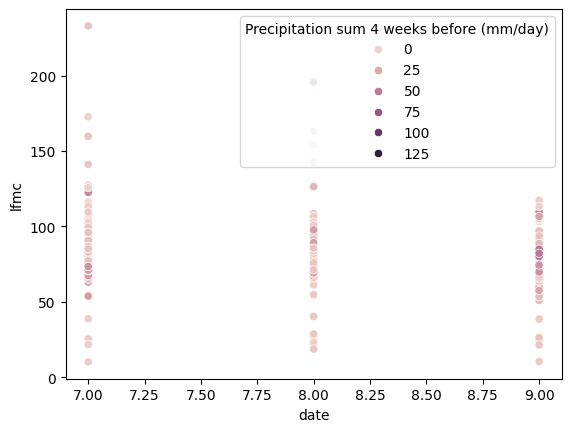

In [120]:
soak = tegl[(tegl['Species collected'].str.contains('Quercus'))&(tegl.Country=='Spain')]
sns.scatterplot(data=soak[(soak.date.dt.month > 6)&(soak.date.dt.month<10)],x=tegl.date.dt.month, y='lfmc', hue='Precipitation sum 4 weeks before (mm/day)')

In [118]:
soak[soak.lfmc>50]['Precipitation sum 4 weeks before (mm/day)'].mean()

np.float64(49.53054911224784)

In [64]:
oak = tegl[tegl['Species collected'].str.contains('Quercus')]
pine = tegl[tegl['Species collected'].str.contains('Pinus')]

<Axes: xlabel='date', ylabel='lfmc'>

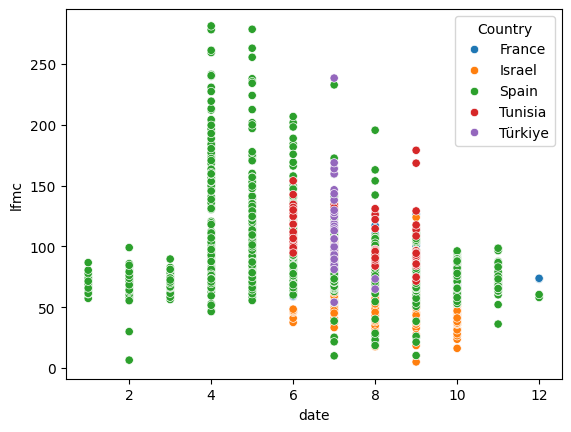

In [114]:
sns.scatterplot(data=oak,x=tegl.date.dt.month, y='lfmc', hue='Country')

In [252]:
oak.groupby('Country')['lfmc'].count().nlargest(10)

Country
France     2386
Spain      1314
Israel      230
Tunisia     100
Türkiye      30
Name: lfmc, dtype: int64

In [253]:
soak = oak[oak['Country'] == "Israel"]

<Axes: xlabel='date', ylabel='lfmc'>

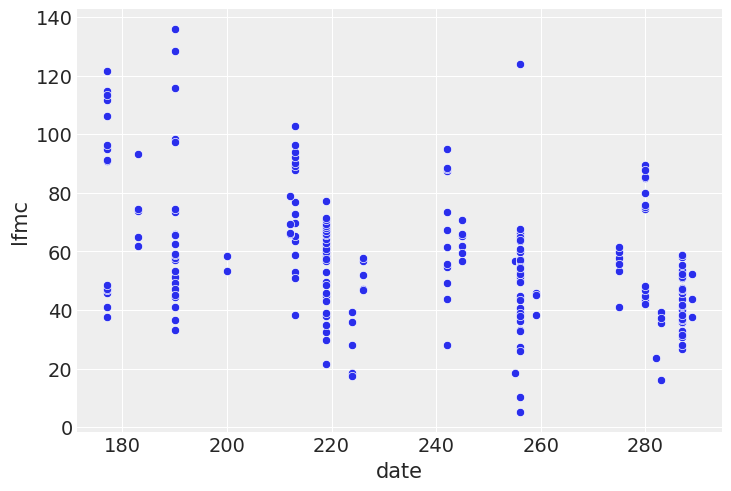

In [254]:
sns.scatterplot(data=soak, x=soak.date.dt.day_of_year, y='lfmc')

In [222]:
oak.columns

Index(['Site name', 'Country', 'State/Region', 'latitude', 'longitude', 'date',
       'lfmc', 'Species collected', 'Species functional type',
       'Individual sample or mean value', 'Old or new leaves',
       'Isolated data point', 'IGBP Land Cover', 'IGBP Land Cover ID',
       'Year of Land Cover', 'Precipitation 24h sum (mm/day)',
       'Precipitation sum 3 days before (mm/day)',
       'Precipitation sum 1 week before (mm/day)',
       'Precipitation sum 4 weeks before (mm/day)',
       'Precipitation sum 12 weeks before (mm/day)',
       '2m Relative Humidity at 06h (%)', '2m Relative Humidity at 09h (%)',
       '2m Relative Humidity at 12h (%)', '2m Relative Humidity at 15h (%)',
       '2m Air Temperature 24h max (K)', '2m Air Temperature 24h mean (K)',
       'Vapour Pressure 24h mean (hPa)', '10m Wind Speed 24h mean (m/s)',
       '2m Dewpoint Temperature 24h mean (K)', 'latind', 'lonind'],
      dtype='str')

<Axes: xlabel='date', ylabel='lfmc'>

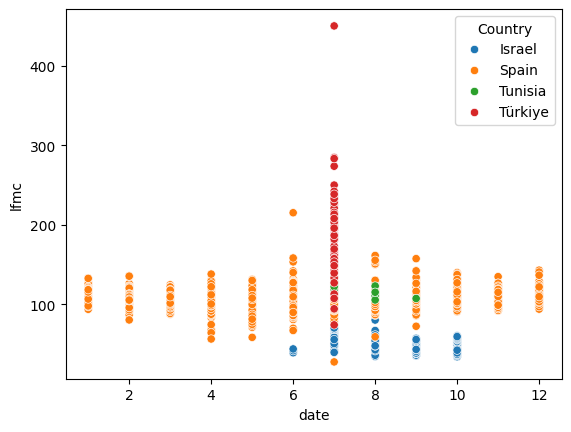

In [112]:
sns.scatterplot(data=pine,x=tegl.date.dt.month, y='lfmc', hue='Country')

In [78]:
pine[pine.lfmc>70]['Vapour Pressure 24h mean (hPa)'].quantile(.95)

np.float64(21.62690029144287)

In [79]:
pine[pine.lfmc<70]['Vapour Pressure 24h mean (hPa)'].quantile(.95)

np.float64(22.16449356079102)

In [80]:
pine['Site name'].value_counts()

Site name
L'Aguda             399
Els Llaures         393
La Pinassa Plana    383
Puig Cabirol        383
Mafla               165
                   ... 
V18                   1
V22                   1
V23                   1
V24                   1
Karabağlar15          1
Name: count, Length: 79, dtype: int64

In [101]:
alepo = pine[pine['Species collected']=="Pinus halepensis"]

In [96]:
arapre['Species collected'].value_counts()

Species collected
Pinus halepensis    165
Name: count, dtype: int64

<Axes: xlabel='date', ylabel='Vapour Pressure 24h mean (hPa)'>

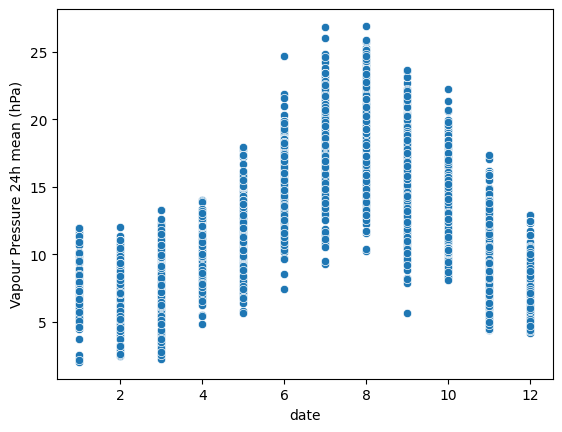

In [103]:
sns.scatterplot(data=alepo, x=alepo.date.dt.month, y='Vapour Pressure 24h mean (hPa)')

<Axes: xlabel='date', ylabel='lfmc'>

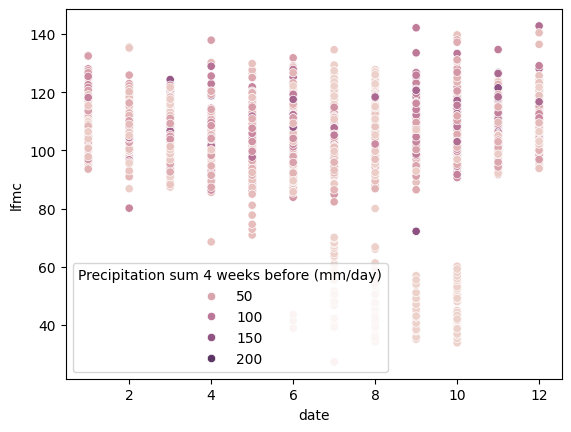

In [123]:
sns.scatterplot(data=alepo, x=alepo.date.dt.month, y='lfmc', hue='Precipitation sum 4 weeks before (mm/day)')

In [125]:
alepo[alepo.date.dt.month ==8].groupby('Country')['Precipitation sum 4 weeks before (mm/day)'].quantile(.75)

Country
Israel      1.730
Spain      47.225
Tunisia     3.460
Name: Precipitation sum 4 weeks before (mm/day), dtype: float64

<Axes: xlabel='date', ylabel='Precipitation sum 4 weeks before (mm/day)'>

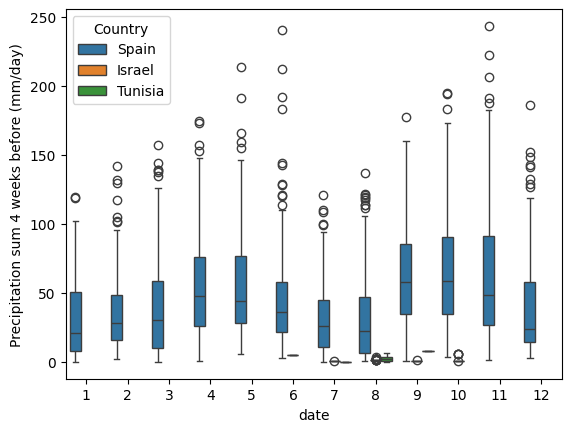

In [127]:
sns.boxplot(data=alepo, x=alepo.date.dt.month, y='Precipitation sum 4 weeks before (mm/day)', hue='Country')

In [108]:
alepo[alepo.lfmc<70]['Vapour Pressure 24h mean (hPa)'].mean()

np.float64(12.831157294344413)

In [129]:
segl = egl[(egl['Species functional type'] == 'Shrub')&(egl['Isolated data point']==False)]

In [132]:
segl['Species collected'].value_counts().nlargest(20)

Species collected
Cistus monspeliensis      5972
Quercus coccifera         4808
Rosmarinus officinalis    3911
Erica arborea             3041
Salvia rosmarinus         2785
Cistus albidus            2077
Juniperus oxycedrus       1106
Arbutus unedo             1029
Phillyrea angustifolia    1008
Erica scoparia             982
Genista cinerea            973
Pistacia lentiscus         859
Buxus sempervirens         790
Cistus ladanifer           752
Calluna vulgaris           412
Calicotome spinosa         392
Erica spp.                 386
Rhamnus alaternus          375
Genista scorpius           373
Ephedra foeminea           339
Name: count, dtype: int64

<Axes: xlabel='date', ylabel='Precipitation sum 4 weeks before (mm/day)'>

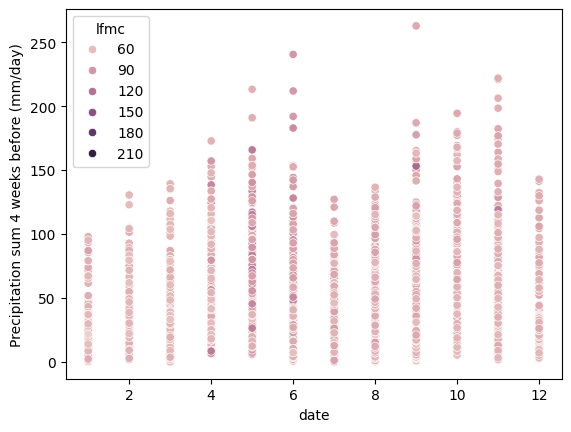

In [144]:
hsegl = segl[segl['Species collected'] == 'Quercus coccifera']
sns.scatterplot(data=hsegl, x=hsegl.date.dt.month,y='Precipitation sum 4 weeks before (mm/day)', hue='lfmc')

In [53]:
fr.groupby(['Species functional type'])['lfmc'].max()

Species functional type
Shrub    286.40
Tree     261.92
Name: lfmc, dtype: float64

In [60]:
fr['month'] = fr.date.dt.month

<Axes: xlabel='month', ylabel='lfmc'>

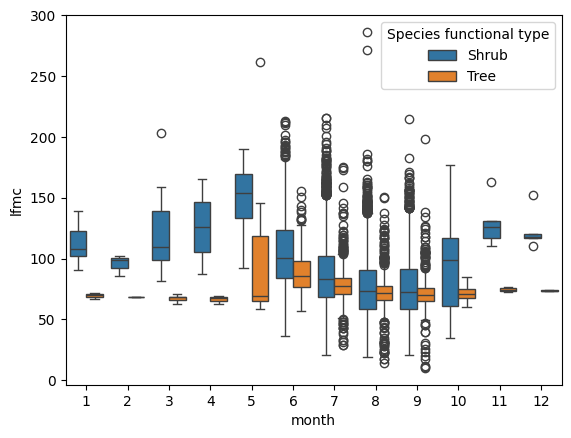

In [62]:
sns.boxplot(data=fr, x='month', y='lfmc', hue='Species functional type')

<Axes: xlabel='month', ylabel='lfmc'>

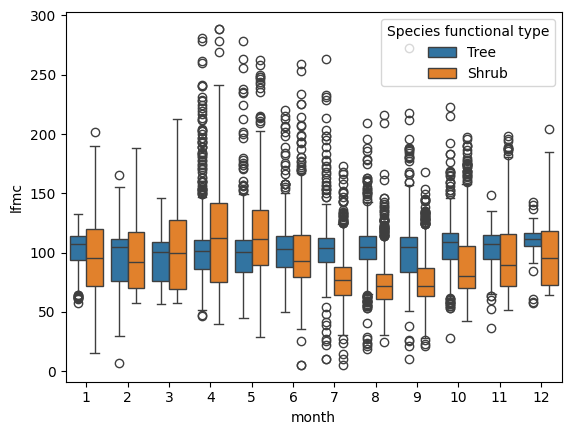

In [71]:
fr = gl[(gl.Country=='Spain')&(gl['Species functional type'].isin(['Tree', 'Shrub'])&(gl.lfmc<300))]
sns.boxplot(data=fr, x='month', y='lfmc', hue='Species functional type')

<Axes: xlabel='month', ylabel='lfmc'>

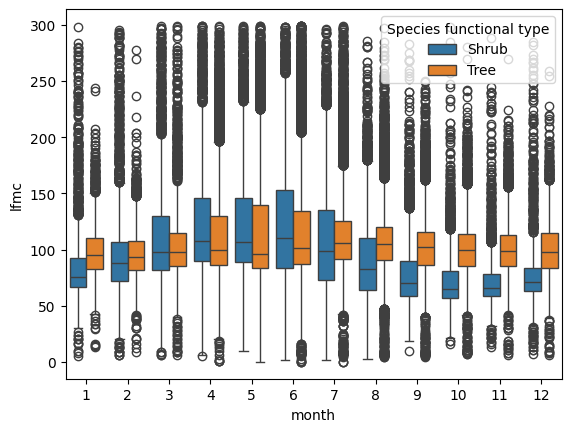

In [69]:
fr = gl[(gl.Country=='USA')&(gl['Species functional type'].isin(['Tree', 'Shrub']))&(gl.lfmc<300)]
sns.boxplot(data=fr, x='month', y='lfmc', hue='Species functional type')

<Axes: xlabel='month', ylabel='lfmc'>

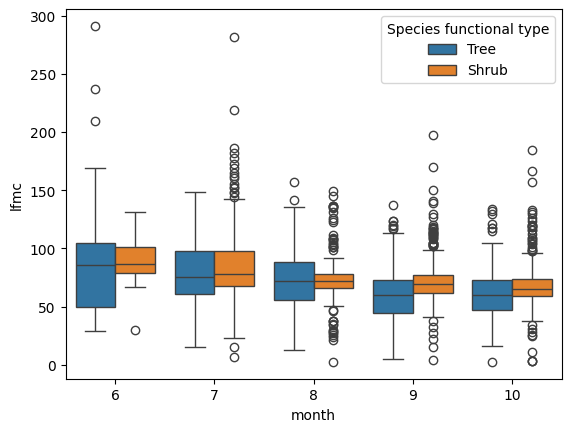

In [70]:
fr = gl[(gl.Country=='Israel')&(gl['Species functional type'].isin(['Tree', 'Shrub']))&(gl.lfmc<300)]
sns.boxplot(data=fr, x='month', y='lfmc', hue='Species functional type')

In [ ]:
def GridSearchOptimizeGSILFM(Temp,LFMDat,label,maxSim = 2,mySeed = 123456,UseLFMMinMax = False,Herb=True,PInt = 20,PLowLim='2015-01-01',PUpperLim='2019-12-31',Lat=45):
    DEBUG = False
      
    # Create a range of smoothing / running precip period length ranges intervals
    smint = range(21,60,7)
    dfsmint = pd.DataFrame(data={'SMInt': smint})
    
    #### Get a Random Set of Parameters
    # Make the VPD ranges
    iVPDP = MakeParamRange(500, 9000, 500)  # VPD ranges from 500 to 9000 Pascals
    # Make the Temperature ranges
    iTMinP = MakeParamRange(-5, 10,1)  # MinT ranges from -5 to 10 deg C
    # Make the Daylength Ranges
    iDaylP = MakeParamRange(32400,46800,3600)  # Dayl ranges from 9 to 13 hours
    # Make the Prcp ranges
    iPrcpP = MakeParamRange(0,50,1)
    iPrcpP = (iPrcpP/10)  # Precip ranges from 0 to 5 inches

    # Make the green-up threshold 
    iThreshP = []
    for i in range(0,81,10):
        iThreshP.append(float(i/100))
    iThreshP = pd.DataFrame(data={'iThresh': iThreshP})    
    
    BestS = 0
    BestParams = []
    
    for i in range(0,maxSim):
        
        rs = dfsmint.sample(n=1,random_state=mySeed+i)
        smint = rs.iloc[0].SMInt.astype(int)
        
        # VPD Params
        rs = iVPDP.sample(n=1,random_state=mySeed+i)
        iVPDMin = rs.iloc[0].Lower
        iVPDMax = rs.iloc[0].Upper
        
        # TMin Params
        rs = iTMinP.sample(n=1,random_state=mySeed+i)
        iTminMin = rs.iloc[0].Lower
        iTminMax = rs.iloc[0].Upper

        # Daylength Params
        rs = iDaylP.sample(n=1,random_state=mySeed+i)
        iDaylMin = rs.iloc[0].Lower
        iDaylMax = rs.iloc[0].Upper

        # RT Precip Params
        rs = iPrcpP.sample(n=1,random_state=mySeed+i)
        iPrcpMin = rs.iloc[0].Lower
        iPrcpMax = rs.iloc[0].Upper

        # Greenup Threshold 
        rs = iThreshP.sample(n=1,random_state=mySeed+i)
        iThreshVal = rs.iloc[0].iThresh.astype(float)
        
        Params = [iTminMin,iTminMax,iVPDMin,iVPDMax,iDaylMin,iDaylMax,iPrcpMin,iPrcpMax,smint,iThreshVal,smint]
               
        S =  MakeGSILFMCompareTable4Param(Temp,LFMDat,Params,label=label,UseLFMMinMax = UseLFMMinMax,Herb=Herb,PLowLim=PLowLim,PUpperLim=PUpperLim,Lat=Lat)
        
        if(S[1] > BestS):
            BestS = S[1]
            BestParams = Params
           
        if i % PInt == 0:
            print(S,BestS,BestParams)
    return(BestParams)